In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [3]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [4]:
print("Mean:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].mean())

print("\nMedian:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].median())

print("\nMode:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].mode().iloc[0])

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date data type:", df["Date"].dtype)
print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Date data type: datetime64[ns]

Date range:
2023-01-01 00:00:00 to 2024-01-01 00:00:00


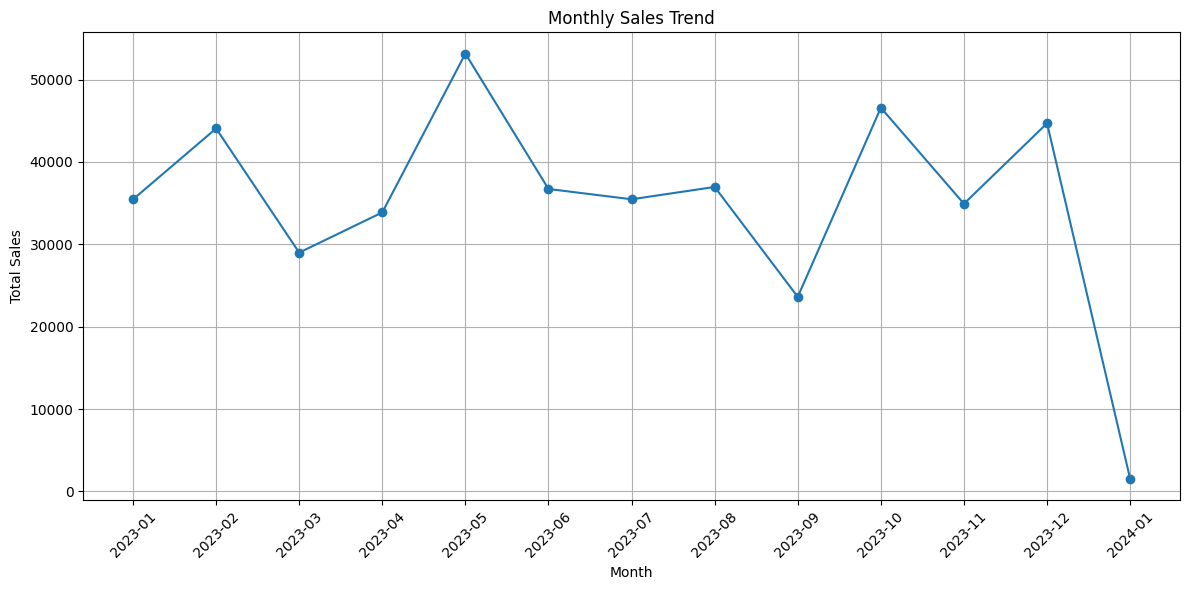

In [6]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total Amount"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

The monthly sales trend shows noticeable fluctuations throughout the year.

- Sales reached the highest level in May 2023.
- Sales declined significantly in September 2023.
- Sales increased again in October 2023.
- December 2023 also recorded strong sales.
- January 2024 shows a sharp decline compared with the previous month.

Overall, the sales pattern is not consistent and shows significant month-to-month variation.

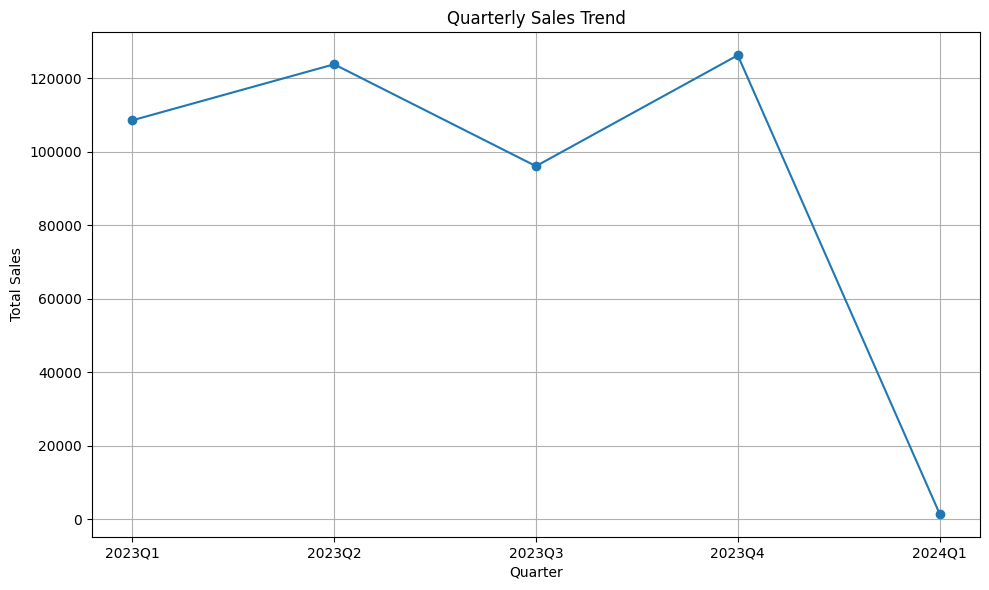

In [7]:
quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(10, 6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend shows noticeable variation across the observed periods.

- Sales increased from Q1 to Q2 in 2023.
- Sales declined during Q3 2023.
- Sales recovered strongly in Q4 2023.
- Q4 2023 recorded one of the highest quarterly sales levels.
- Q1 2024 shows a sharp decline because the dataset contains only January 2024 data for this quarter.

Overall, quarterly sales show fluctuations rather than a consistent upward or downward trend.

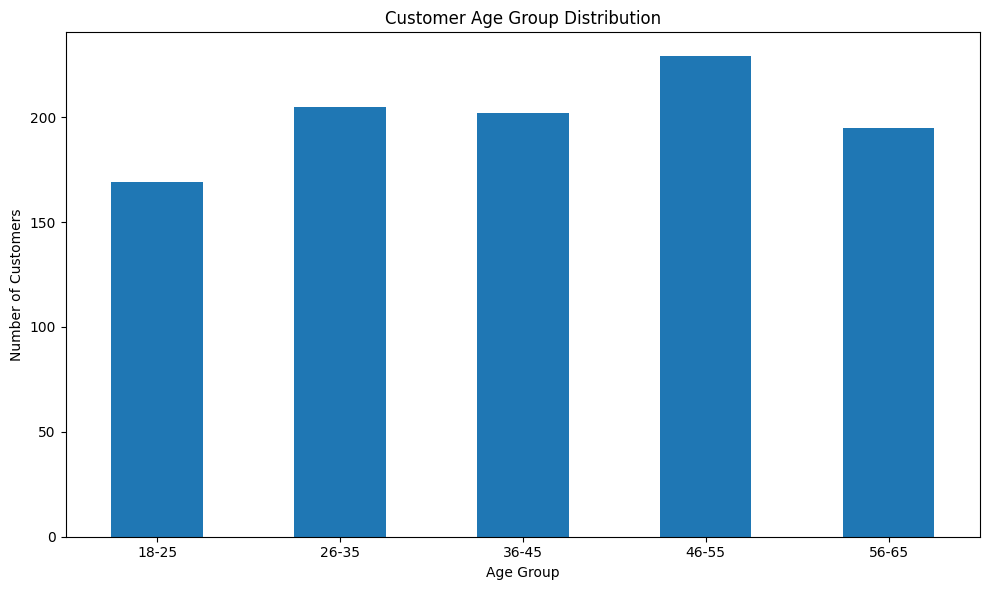

In [8]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
age_group_counts.plot(kind="bar")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation – Customer Age Group Distribution

The customer age distribution shows variation across different age groups.

- The 46–55 age group has the highest number of customers.
- The 26–35 age group also represents a significant customer segment.
- The 18–25 age group has comparatively fewer customers.
- Customers are distributed across all five age groups.

This indicates that the business serves customers across a broad range of age groups, with stronger representation from middle-aged customers.

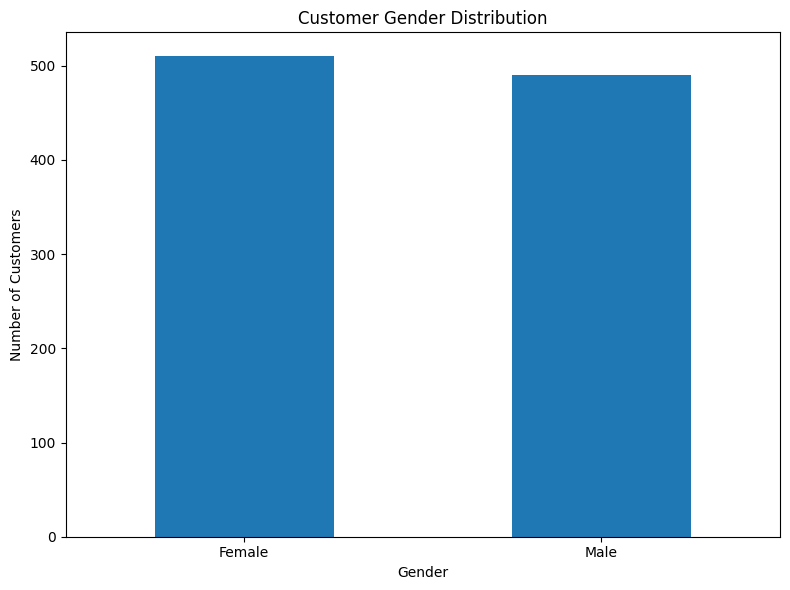

In [9]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(8, 6))
gender_counts.plot(kind="bar")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

## Observation – Customer Gender Distribution

The customer gender distribution is relatively balanced.

- Female customers are slightly higher, with 510 customers.
- Male customers account for 490 customers.
- The difference between female and male customers is small.

Overall, the dataset shows a balanced customer base across both genders.

In [11]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

print("Sales by Product Category:")
print(category_sales)

Sales by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


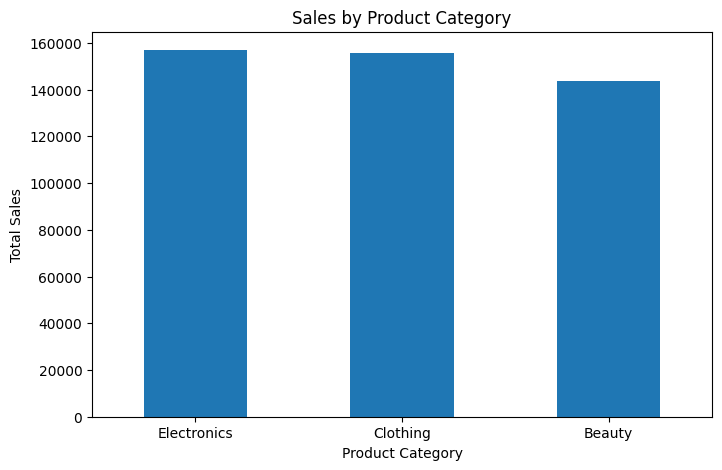

In [14]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

## Observation – Sales by Product Category

The sales analysis shows differences across the three product categories.

- Electronics generated the highest total sales of 156,905.
- Clothing generated 155,580 in total sales and performed almost as well as Electronics.
- Beauty generated 143,515 in total sales, which was the lowest among the three categories.
- Electronics and Clothing together contributed the majority of total sales.

Overall, Electronics and Clothing are the strongest-performing product categories in terms of total sales.

In [15]:
gender_sales = df.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)

print("Sales by Gender:")
print(gender_sales)

Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


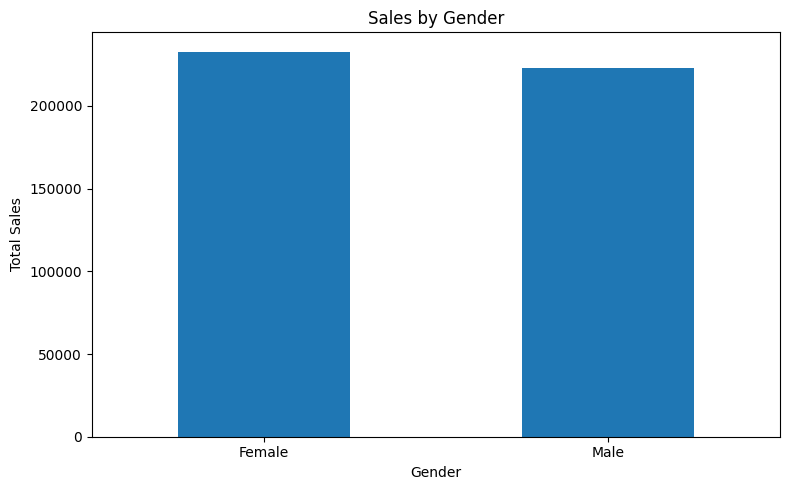

In [16]:
gender_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Observation – Sales by Gender

The sales analysis by gender shows a relatively balanced contribution from both customer groups.

- Female customers generated total sales of 232,840.
- Male customers generated total sales of 223,160.
- Female customers contributed slightly higher sales than male customers.
- The difference in sales between both genders is relatively small.

Overall, sales are fairly balanced across both genders, with female customers contributing slightly more.

In [18]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["age_group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

print("Age Group created successfully!")
print(df[["Age", "age_group"]].head())

Age Group created successfully!
   Age age_group
0   34     26-35
1   26     26-35
2   50     46-55
3   37     36-45
4   30     26-35


In [19]:
# Sales by Age Group
age_group_sales = df.groupby("age_group")["Total Amount"].sum().sort_values(ascending=False)

print("Sales by Age Group:")
print(age_group_sales)

Sales by Age Group:
age_group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-65     80410
Name: Total Amount, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_1944\2457378507.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby("age_group")["Total Amount"].sum().sort_values(ascending=False)


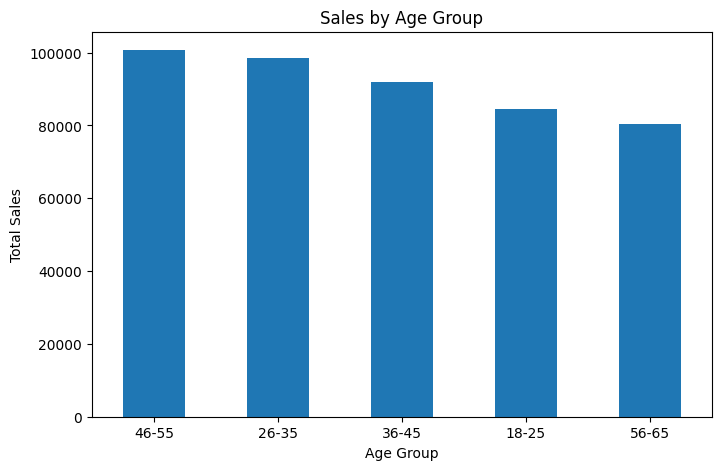

In [20]:
import matplotlib.pyplot as plt

age_group_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

## Observation – Sales by Age Group

The sales analysis by age group shows differences in total sales across customer segments.

- The 46–55 age group generated the highest total sales of 100,690.
- The 26–35 age group generated 98,480 in total sales.
- The 36–45 age group generated 91,870 in total sales.
- The 18–25 age group generated 84,550 in total sales.
- The 56–65 age group generated the lowest total sales of 80,410.

Overall, customers in the 46–55 and 26–35 age groups contributed the highest sales, while the 56–65 age group contributed the lowest.

In [21]:
# Sales by Age Group and Gender

age_gender_sales = df.groupby(
    ["age_group", "Gender"]
)["Total Amount"].sum().unstack()

print("Sales by Age Group and Gender:")
print(age_gender_sales)

Sales by Age Group and Gender:
Gender     Female   Male
age_group               
18-25       39470  45080
26-35       55115  43365
36-45       46735  45135
46-55       53310  47380
56-65       38210  42200


C:\Users\Admin\AppData\Local\Temp\ipykernel_1944\999903406.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_sales = df.groupby(


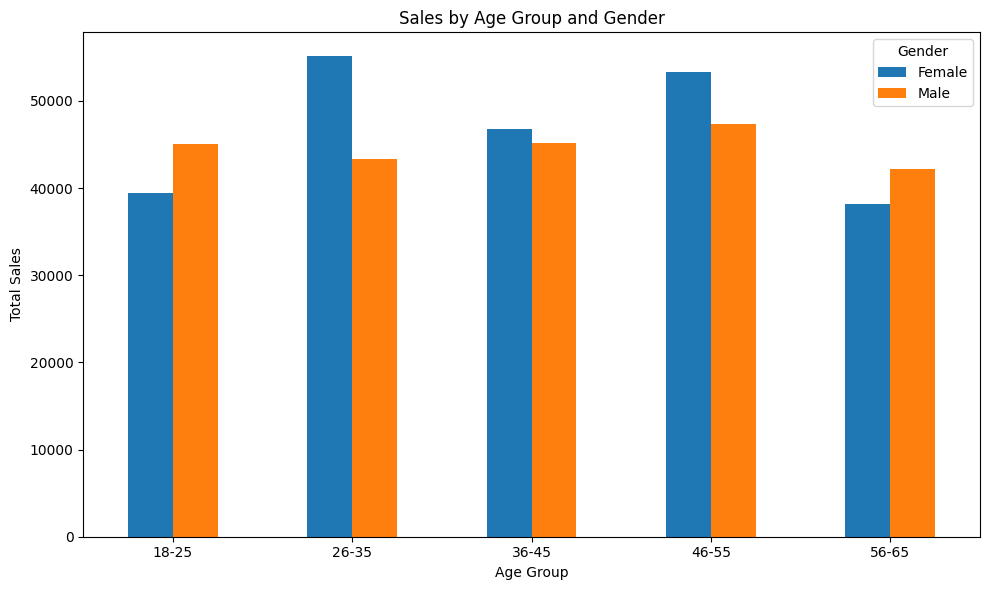

In [22]:
# Sales by Age Group and Gender - Chart

age_gender_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Observation – Sales by Age Group and Gender

The sales analysis by age group and gender shows differences in purchasing contribution across customer segments.

- The 26–35 age group has the highest female sales contribution.
- The 46–55 age group also shows strong sales from both genders.
- In the 18–25 and 56–65 age groups, male customers generated higher sales than female customers.
- Female customers generated higher sales in the 26–35, 36–45, and 46–55 age groups.

Overall, sales contribution varies by both age group and gender, with middle-aged customer segments showing strong sales performance.

In [23]:
# Percentage contribution by Age Group and Gender

age_gender_percentage = age_gender_sales.copy()

age_gender_percentage["Total Sales"] = age_gender_percentage.sum(axis=1)

age_gender_percentage["Female %"] = (
    age_gender_percentage["Female"] /
    age_gender_percentage["Total Sales"] * 100
)

age_gender_percentage["Male %"] = (
    age_gender_percentage["Male"] /
    age_gender_percentage["Total Sales"] * 100
)

print("Sales Percentage by Age Group and Gender:")
print(age_gender_percentage[["Female %", "Male %"]].round(2))

Sales Percentage by Age Group and Gender:
Gender     Female %  Male %
age_group                  
18-25         46.68   53.32
26-35         55.97   44.03
36-45         50.87   49.13
46-55         52.94   47.06
56-65         47.52   52.48


## Observation – Sales Percentage by Age Group and Gender

The percentage analysis shows differences in sales contribution between female and male customers across age groups.

- Female customers contributed a higher percentage of sales in the 26–35, 36–45, and 46–55 age groups.
- Male customers contributed a higher percentage of sales in the 18–25 and 56–65 age groups.
- The 26–35 age group shows the highest female contribution at 55.97%.
- The 18–25 age group shows the highest male contribution at 53.32%.
- The differences between male and female sales contributions are relatively small.

Overall, sales contribution is fairly balanced across genders, with variations across different age groups.

In [24]:
# Sales by Product Category and Gender

category_gender_sales = df.groupby(
    ["Product Category", "Gender"]
)["Total Amount"].sum().unstack()

print("Sales by Product Category and Gender:")
print(category_gender_sales)

Sales by Product Category and Gender:
Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


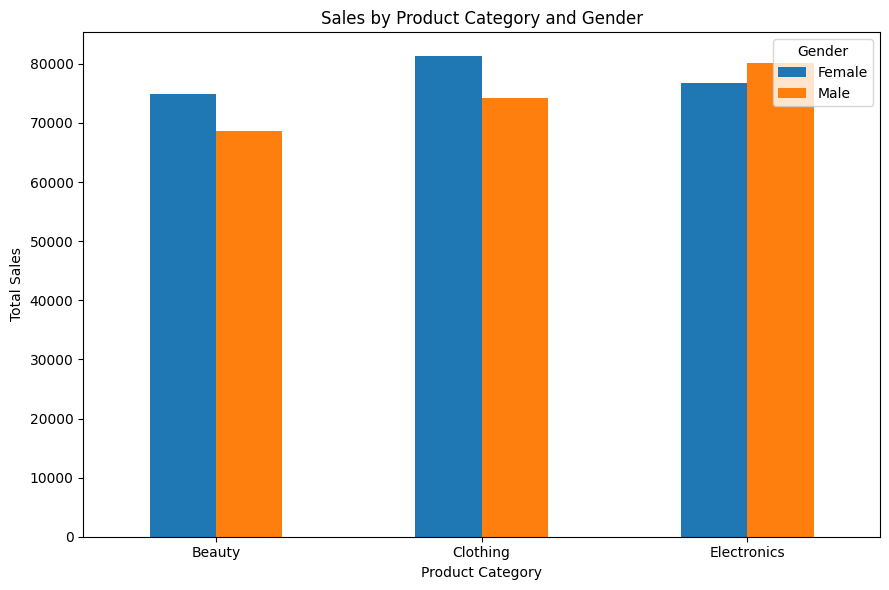

In [25]:
# Sales by Product Category and Gender - Chart

category_gender_sales.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Sales by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Observation – Sales by Product Category and Gender

The sales analysis by product category and gender shows differences in purchasing contribution across customer groups.

- Female customers generated higher sales than male customers in Beauty.
- Female customers also generated higher sales than male customers in Clothing.
- Male customers generated higher sales than female customers in Electronics.
- Clothing recorded the highest female sales contribution.
- Electronics recorded the highest male sales contribution.

Overall, female customers contributed higher sales in Beauty and Clothing, while male customers contributed higher sales in Electronics.

In [26]:
# Percentage contribution by Product Category and Gender

category_gender_percentage = category_gender_sales.copy()

category_gender_percentage["Total Sales"] = category_gender_percentage.sum(axis=1)

category_gender_percentage["Female %"] = (
    category_gender_percentage["Female"] /
    category_gender_percentage["Total Sales"] * 100
)

category_gender_percentage["Male %"] = (
    category_gender_percentage["Male"] /
    category_gender_percentage["Total Sales"] * 100
)

print("Sales Percentage by Product Category and Gender:")
print(
    category_gender_percentage[["Female %", "Male %"]].round(2)
)

Sales Percentage by Product Category and Gender:
Gender            Female %  Male %
Product Category                  
Beauty               52.14   47.86
Clothing             52.24   47.76
Electronics          48.91   51.09


## Observation – Sales Percentage by Product Category and Gender

The percentage analysis shows differences in sales contribution between female and male customers across product categories.

- Female customers contributed a higher percentage of sales in Beauty and Clothing.
- Male customers contributed a higher percentage of sales in Electronics.
- Clothing shows the highest female contribution at 52.24%.
- Electronics shows the highest male contribution at 51.09%.
- The differences between female and male sales contributions are relatively small.

Overall, sales contribution is fairly balanced across genders, with slight variations across product categories.

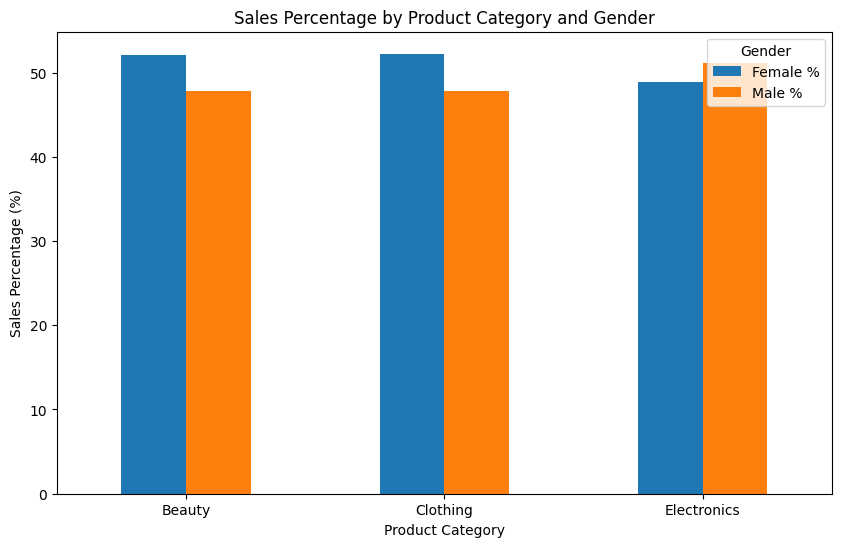

In [27]:
# Percentage Sales by Product Category and Gender

category_gender_percentage[["Female %", "Male %"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales Percentage by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Sales Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.show()

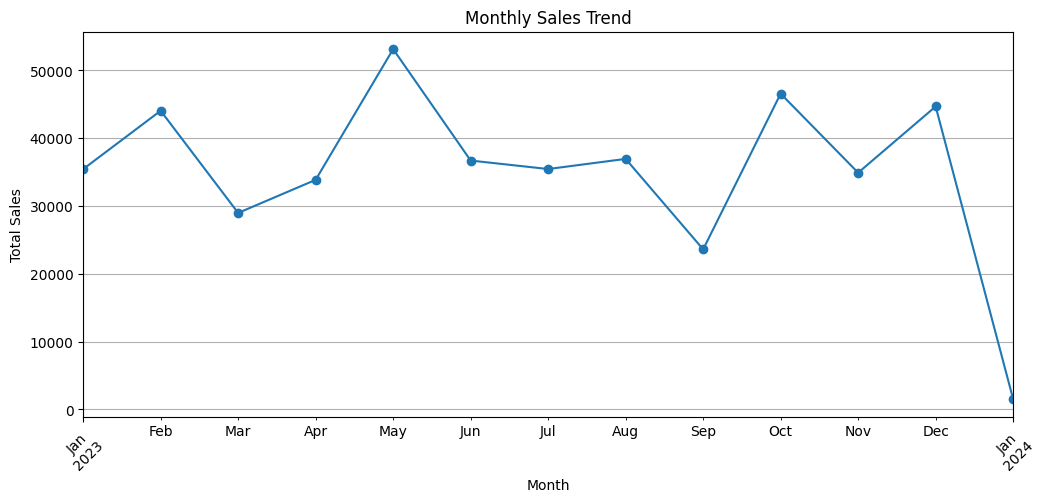

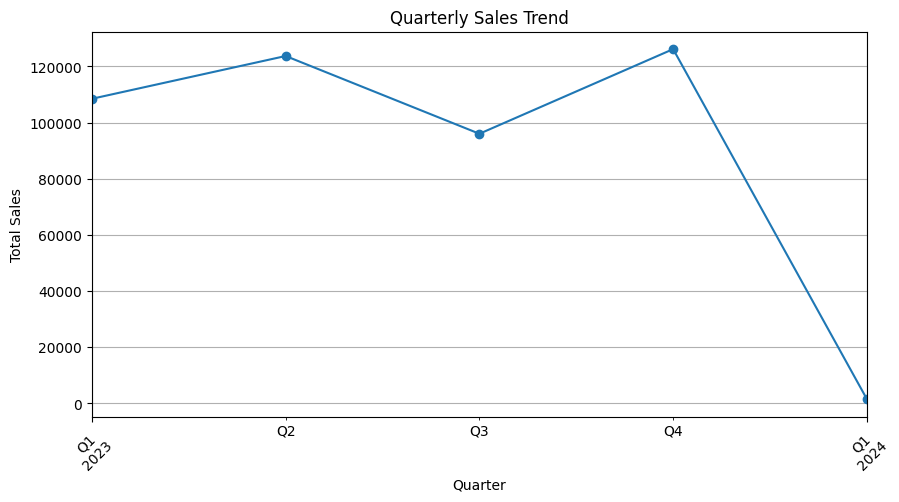

In [28]:
# Monthly and Quarterly Sales Trend

df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total Amount"].sum()

quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

# Monthly Sales Trend
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Quarterly Sales Trend
plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind="line", marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Final Conclusion

The Retail Sales Analysis provided useful insights into customer purchasing behavior based on age group, gender, and product category.

Key findings:
- The 46–55 age group generated the highest total sales.
- The 56–65 age group generated the lowest total sales.
- Female customers contributed higher sales in Beauty and Clothing.
- Male customers contributed higher sales in Electronics.
- Sales contributions between female and male customers were relatively balanced across product categories.
- Clothing showed the highest female sales contribution, while Electronics showed the highest male sales contribution.

Overall, the analysis shows that customer demographics and product categories have an impact on sales performance and can help businesses understand their customer segments better.